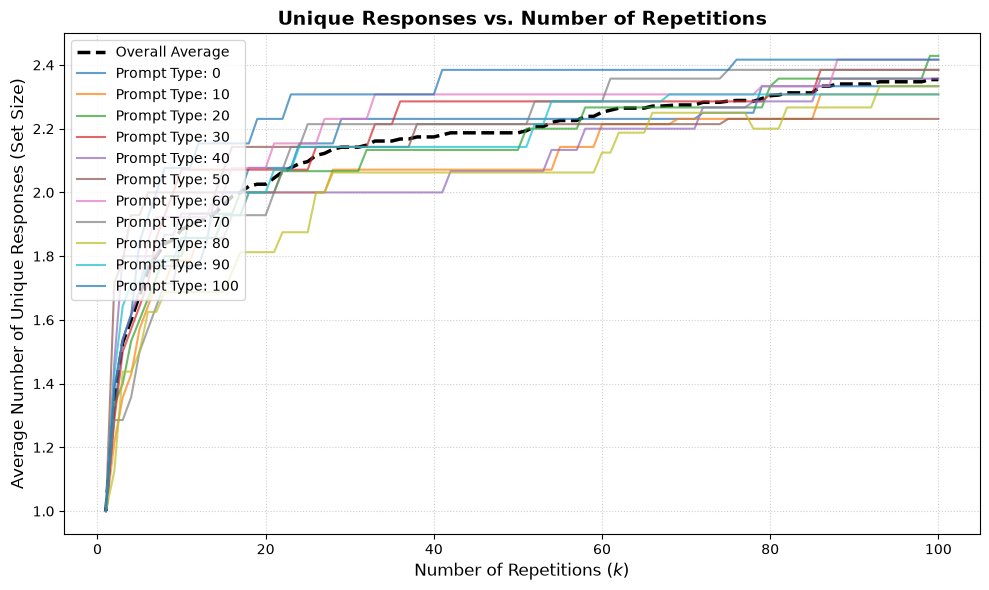

Plot successfully saved to unique_responses_plot.png


In [15]:
import os
import glob
import numpy
import pandas as pd
import matplotlib.pyplot as plt
import spot
import numpy as np
# 1. Specify the folder containing your files
folder_path = './out_repeattest'  # Replace with your actual folder path
file_extension = '*.csv'            # Change to '*.txt' or similar if needed

# 2. Find and combine all files
file_pattern = os.path.join(folder_path, file_extension)
all_files = glob.glob(file_pattern)
def safe_divide(row):
    try:
        return str(spot.formula(row['Response']))
    except:
        # Return NaN, None, or a default fallback value on error
        return np.nan

# Apply row-wise (axis=1)



if not all_files:
    print(f"No files found in '{folder_path}' matching pattern '{file_extension}'")
else:
    dfs = []
    for file in all_files:
        df_file = pd.read_csv(file)
        # Clean column names from any leading/trailing whitespaces
        df_file.columns = df_file.columns.str.strip()
        # Keep track of the filename to differentiate indices across different files
        df_file['filename'] = os.path.basename(file)
        df_file['TEMP'] = int(os.path.basename(file).split('.')[1].split('temp')[1])
    
        df_file['Response'] = df_file.apply(safe_divide, axis=1) 
        dfs.append(df_file)
    
    # Merge all data into a single DataFrame
    df = pd.concat(dfs, ignore_index=True)
    
    # Optional: Drop rows where Response is missing
    df = df.dropna(subset=['Response'])

    # 3. Group by file, prompt type, and index to keep each repetition block isolated
    group_cols = ['filename', 'TEMP', 'Index']
    
    # Calculate the repetition number (1, 2, 3, ..., k) within each group
    df['repetition'] = df.groupby(group_cols).cumcount() + 1
    
    # Calculate the cumulative number of unique responses up to that row
    # This uses a fast vectorized method: ~duplicated() is True for the first occurrence
    df['unique_count'] = df.groupby(group_cols)['Response'].transform(lambda x: (~x.duplicated()).cumsum())

    # 4. Aggregate the data for the plot
    # Option A: Overall average unique responses across all data
    overall_summary = df.groupby('repetition')['unique_count'].mean().reset_index()

    # Option B: Average unique responses broken down by PROMPTTYPE
    prompt_summary = df.groupby(['TEMP', 'repetition'])['unique_count'].mean().reset_index()

    # 5. Generate the plot
    plt.figure(figsize=(10, 6))
    
    # Plot the overall trend
    plt.plot(
        overall_summary['repetition'], 
        overall_summary['unique_count'], 
        label='Overall Average', 
        color='black', 
        linewidth=2.5, 
        linestyle='--'
    )
    
    # Plot separate lines for each PROMPTTYPE to show individual trends
    for prompt_type in prompt_summary['TEMP'].unique():
        sub_df = prompt_summary[prompt_summary['TEMP'] == prompt_type]
        plt.plot(
            sub_df['repetition'], 
            sub_df['unique_count'], 
            label=f'Prompt Type: {prompt_type}', 
            alpha=0.7
        )
        
    # Formatting the chart
    plt.title('Unique Responses vs. Number of Repetitions', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Repetitions ($k$)', fontsize=12)
    plt.ylabel('Average Number of Unique Responses (Set Size)', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=10, loc='upper left')
    plt.tight_layout()
    
    # Save the plot
    output_plot_path = 'unique_responses_plot.png'
    plt.savefig(output_plot_path, dpi=300)
    plt.show()
    
    print(f"Plot successfully saved to {output_plot_path}")

In [16]:
df[df['Index'] == 54]

,PROMPTTYPE,Index,Requirement,Ground Truth,Response,Equivalent,filename,TEMP,repetition,unique_count
700,ARTEMIS,54,Do not enter office_4 until you have picked up...,(!office_4 U p_pass_6) & F(house_5 & F(p_pass_...,!(office_4 U p_pass_6) & F(house_5 & p_pass_6)...,False,data_Qwen_Qwen3.5-27B_ARTEMIS_temp100.csv,100,1,1
701,ARTEMIS,54,Do not enter office_4 until you have picked up...,(!office_4 U p_pass_6) & F(house_5 & F(p_pass_...,!(office_4 U p_pass_6) & F(house_5 & p_pass_6)...,False,data_Qwen_Qwen3.5-27B_ARTEMIS_temp100.csv,100,2,2
702,ARTEMIS,54,Do not enter office_4 until you have picked up...,(!office_4 U p_pass_6) & F(house_5 & F(p_pass_...,!(office_4 U p_pass_6) & F(house_5 & p_pass_6)...,False,data_Qwen_Qwen3.5-27B_ARTEMIS_temp100.csv,100,3,2
703,ARTEMIS,54,Do not enter office_4 until you have picked up...,(!office_4 U p_pass_6) & F(house_5 & F(p_pass_...,!(office_4 U p_pass_6) & F(house_5 & p_pass_6)...,False,data_Qwen_Qwen3.5-27B_ARTEMIS_temp100.csv,100,4,2
704,ARTEMIS,54,Do not enter office_4 until you have picked up...,(!office_4 U p_pass_6) & F(house_5 & F(p_pass_...,!(office_4 U p_pass_6) & F(house_5 & p_pass_6)...,False,data_Qwen_Qwen3.5-27B_ARTEMIS_temp100.csv,100,5,2
...,...,...,...,...,...,...,...,...,...,...
15495,ARTEMIS,54,Do not enter office_4 until you have picked up...,(!office_4 U p_pass_6) & F(house_5 & F(p_pass_...,!(office_4 U p_pass_6) & F(house_5 & p_pass_6)...,False,data_Qwen_Qwen3.5-27B_ARTEMIS_temp80.csv,80,96,2
15496,ARTEMIS,54,Do not enter office_4 until you have picked up...,(!office_4 U p_pass_6) & F(house_5 & F(p_pass_...,!(office_4 U p_pass_6) & F(house_5 & p_pass_6)...,False,data_Qwen_Qwen3.5-27B_ARTEMIS_temp80.csv,80,97,2
15497,ARTEMIS,54,Do not enter office_4 until you have picked up...,(!office_4 U p_pass_6) & F(house_5 & F(p_pass_...,!(office_4 U p_pass_6) & F(house_5 & p_pass_6)...,False,data_Qwen_Qwen3.5-27B_ARTEMIS_temp80.csv,80,98,2
15498,ARTEMIS,54,Do not enter office_4 until you have picked up...,(!office_4 U p_pass_6) & F(house_5 & F(p_pass_...,!(office_4 U p_pass_6) & F(house_5 & p_pass_6)...,False,data_Qwen_Qwen3.5-27B_ARTEMIS_temp80.csv,80,99,2



        PARETO TRADE-OFF ANALYSIS        
Overall Best Pareto Point: 18 repetitions
Expected unique responses at this point: 2.02
----------------------------------------
Prompt Type '0' Best Pareto Point: 29 repetitions (Uniques: 2.23)
Prompt Type '10' Best Pareto Point: 18 repetitions (Uniques: 2.00)
Prompt Type '20' Best Pareto Point: 11 repetitions (Uniques: 1.93)
Prompt Type '30' Best Pareto Point: 10 repetitions (Uniques: 2.07)
Prompt Type '40' Best Pareto Point: 10 repetitions (Uniques: 1.93)
Prompt Type '50' Best Pareto Point: 16 repetitions (Uniques: 2.14)
Prompt Type '60' Best Pareto Point: 21 repetitions (Uniques: 2.15)
Prompt Type '70' Best Pareto Point: 25 repetitions (Uniques: 2.21)
Prompt Type '80' Best Pareto Point: 28 repetitions (Uniques: 2.06)
Prompt Type '90' Best Pareto Point: 24 repetitions (Uniques: 2.14)
Prompt Type '100' Best Pareto Point: 12 repetitions (Uniques: 2.15)



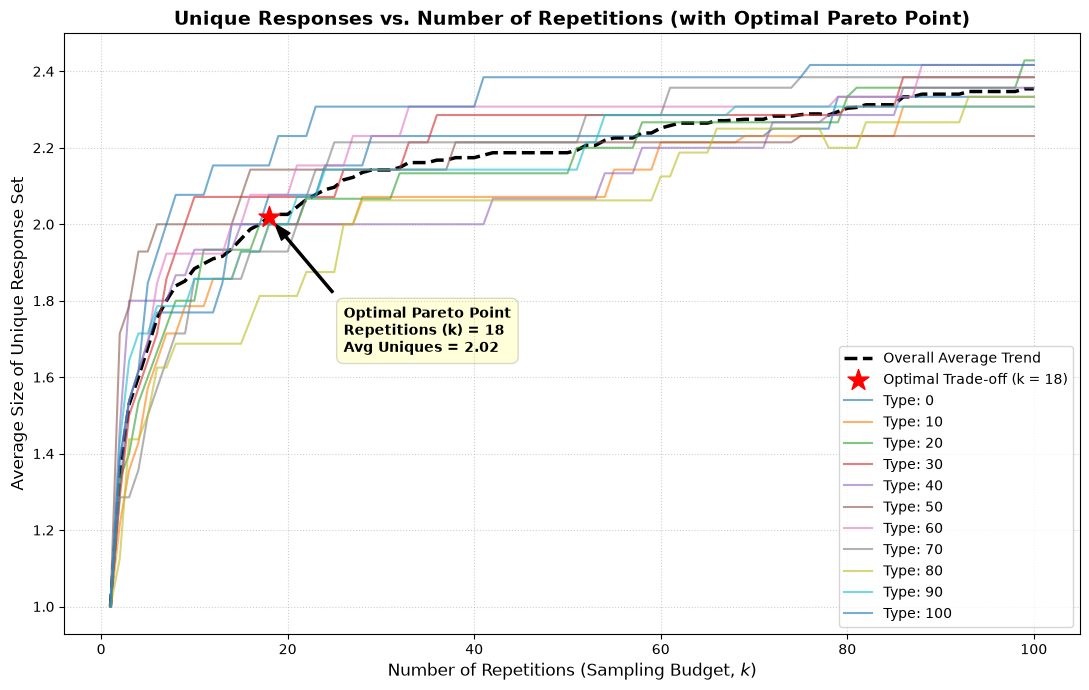

Plot with Pareto Trade-off saved successfully to: unique_responses_pareto_plot.png


In [17]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_knee_point(x, y):
    """
    Finds the knee/elbow point of a curve using the maximum perpendicular distance method.
    """
    x = np.array(x)
    y = np.array(y)
    
    if len(x) < 3:
        return x[0], y[0]
        
    # Line starting point (p1) and ending point (p2)
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    
    # Vector representing the straight line connecting start and end
    line_vec = p2 - p1
    line_len = np.linalg.norm(line_vec)
    if line_len == 0:
        return x[0], y[0]
    line_unit_vec = line_vec / line_len
    
    # Find perpendicular distance from each point to the line
    distances = []
    for xi, yi in zip(x, y):
        p = np.array([xi, yi])
        v = p - p1
        # Project vector v onto the line
        proj = np.dot(v, line_unit_vec) * line_unit_vec
        # The perpendicular vector is the difference between v and its projection
        dist = np.linalg.norm(v - proj)
        distances.append(dist)
        
    # The index with the maximum distance is the knee point
    knee_idx = np.argmax(distances)
    return x[knee_idx], y[knee_idx]

# 1. Specify the folder containing your files
folder_path = './out_repeattest'  # Replace with your actual folder path
file_extension = '*.csv'            # Change to '*.txt' or similar if needed

# 2. Find and combine all files
file_pattern = os.path.join(folder_path, file_extension)
all_files = glob.glob(file_pattern)

if not all_files:
    print(f"No files found in '{folder_path}' matching pattern '{file_extension}'")
else:
    dfs = []
    for file in all_files:
        df_file = pd.read_csv(file)
        df_file.columns = df_file.columns.str.strip()
        df_file['filename'] = os.path.basename(file)
        df_file['TEMP'] = int(os.path.basename(file).split('.')[1].split('temp')[1])
        df_file['Response'] = df_file.apply(safe_divide, axis=1) 
        dfs.append(df_file)
    
    df = pd.concat(dfs, ignore_index=True).dropna(subset=['Response'])

    # 3. Process repetitions and unique counts
    group_cols = ['filename', 'TEMP', 'Index']
    df['repetition'] = df.groupby(group_cols).cumcount() + 1
    df['unique_count'] = df.groupby(group_cols)['Response'].transform(lambda x: (~x.duplicated()).cumsum())

    # 4. Aggregate data
    overall_summary = df.groupby('repetition')['unique_count'].mean().reset_index()
    prompt_summary = df.groupby(['TEMP', 'repetition'])['unique_count'].mean().reset_index()

    # 5. Calculate the exact Knee Points
    overall_x = overall_summary['repetition'].values
    overall_y = overall_summary['unique_count'].values
    knee_x, knee_y = find_knee_point(overall_x, overall_y)
    
    print("\n" + "="*40)
    print("        PARETO TRADE-OFF ANALYSIS        ")
    print("="*40)
    print(f"Overall Best Pareto Point: {knee_x} repetitions")
    print(f"Expected unique responses at this point: {knee_y:.2f}")
    print("-"*40)

    # Calculate individual knee points for each PROMPTTYPE
    knee_points_by_type = {}
    for p_type in prompt_summary['TEMP'].unique():
        sub_df = prompt_summary[prompt_summary['TEMP'] == p_type]
        pt_x = sub_df['repetition'].values
        pt_y = sub_df['unique_count'].values
        pt_knee_x, pt_knee_y = find_knee_point(pt_x, pt_y)
        knee_points_by_type[p_type] = (pt_knee_x, pt_knee_y)
        print(f"Prompt Type '{p_type}' Best Pareto Point: {pt_knee_x} repetitions (Uniques: {pt_knee_y:.2f})")
    print("="*40 + "\n")

    # 6. Generate the plot
    plt.figure(figsize=(11, 7))
    
    # Plot the overall trend
    plt.plot(
        overall_x, 
        overall_y, 
        label='Overall Average Trend', 
        color='black', 
        linewidth=2.5, 
        linestyle='--'
    )
    
    # Highlight the overall knee point on the graph
    plt.scatter(
        knee_x, 
        knee_y, 
        color='red', 
        marker='*', 
        s=250, 
        zorder=5, 
        label=f'Optimal Trade-off (k = {knee_x})'
    )
    
    # Annotate the knee point
    plt.annotate(
        f'Optimal Pareto Point\nRepetitions (k) = {knee_x}\nAvg Uniques = {knee_y:.2f}',
        xy=(knee_x, knee_y),
        xytext=(knee_x + (max(overall_x)*0.08), knee_y - (max(overall_y)*0.15)),
        arrowprops=dict(facecolor='black', shrink=0.08, width=1.5, headwidth=8),
        fontsize=10,
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.5", fc="yellow", alpha=0.15)
    )
    
    # Plot separate lines for each PROMPTTYPE
    for p_type in prompt_summary['TEMP'].unique():
        sub_df = prompt_summary[prompt_summary['TEMP'] == p_type]
        plt.plot(
            sub_df['repetition'], 
            sub_df['unique_count'], 
            label=f'Type: {p_type}', 
            alpha=0.6
        )
        
    # Polish the plot
    plt.title('Unique Responses vs. Number of Repetitions (with Optimal Pareto Point)', fontsize=14, fontweight='bold')
    plt.xlabel('Number of Repetitions (Sampling Budget, $k$)', fontsize=12)
    plt.ylabel('Average Size of Unique Response Set', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(fontsize=10, loc='lower right')
    plt.tight_layout()
    
    # Save and display
    output_plot_path = 'unique_responses_pareto_plot.png'
    plt.savefig(output_plot_path, dpi=300)
    plt.show()
    
    print(f"Plot with Pareto Trade-off saved successfully to: {output_plot_path}")

In [7]:
os.path.basename(file).split('.')[1]

'5-27B_BASIC_temp30'